<a href="https://colab.research.google.com/github/R-Anand123/Computer_vision/blob/Meenakshi/Computervision_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LIBRARIES

In [10]:
import os
import cv2
import numpy as np

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout

#  Explore dataset structure

In [11]:
dataset_path = "/content/dataset"

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")


# Load images into X_all, y_all

In [12]:
dataset_path = "/content/drive/MyDrive/AI ML/Data/Multi-class Weather Dataset" # Corrected path
IMG_SIZE = 128

X_all = []
y_all = []

classes = sorted(os.listdir(dataset_path))

for label in classes:
    class_folder = os.path.join(dataset_path, label)
    if not os.path.isdir(class_folder):
        continue
    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X_all.append(img)
        y_all.append(label)

X_all = np.array(X_all)
y_all = np.array(y_all)

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#  Encode labels

In [14]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_all)
y_categorical = to_categorical(y_encoded)



# Train/test split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


# Normalize images

In [16]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Build CNN

In [17]:
num_classes = y_categorical.shape[1]

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# VGG model

In [18]:
# Safety checks before building
assert X_train.shape[1:] == (IMG_SIZE, IMG_SIZE, 3), "Image shape doesn't match IMG_SIZE"
assert num_classes > 1, "num_classes looks wrong — check y_categorical"

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False  # freeze pretrained layers so they don't retrain

vgg_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 66,180 (258.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

# Compile and train

In [21]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

cnn_history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=16
)

Epoch 1/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 457ms/step - accuracy: 0.9267 - loss: 0.2213 - val_accuracy: 0.9022 - val_loss: 0.4602
Epoch 2/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 24s 418ms/step - accuracy: 0.9767 - loss: 0.0787 - val_accuracy: 0.8800 - val_loss: 0.4334
Epoch 3/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 41s 425ms/step - accuracy: 0.9856 - loss: 0.0510 - val_accuracy: 0.8978 - val_loss: 0.3000
Epoch 4/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 40s 416ms/step - accuracy: 0.9900 - loss: 0.0355 - val_accuracy: 0.9022 - val_loss: 0.2882
Epoch 5/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 26s 451ms/step - accuracy: 0.9456 - loss: 0.1856 - val_accuracy: 0.8889 - val_loss: 0.4382


In [20]:
vgg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

vgg_history = vgg_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=16
)

Epoch 1/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 254s 4s/step - accuracy: 0.5822 - loss: 1.0406 - val_accuracy: 0.7067 - val_loss: 0.7294
Epoch 2/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 270s 5s/step - accuracy: 0.8078 - loss: 0.6083 - val_accuracy: 0.8267 - val_loss: 0.5227
Epoch 3/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 223s 4s/step - accuracy: 0.8367 - loss: 0.4732 - val_accuracy: 0.8311 - val_loss: 0.4483
Epoch 4/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 223s 4s/step - accuracy: 0.8656 - loss: 0.3909 - val_accuracy: 0.8444 - val_loss: 0.3946
Epoch 5/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 297s 5s/step - accuracy: 0.8867 - loss: 0.3368 - val_accuracy: 0.8667 - val_loss: 0.3470


# Evaluate

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.8889 - loss: 0.4382
Custom CNN Test Accuracy: 0.8889
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step

Classification Report (Custom CNN):
              precision    recall  f1-score   support

      Cloudy       0.92      0.75      0.83        60
        Rain       0.81      1.00      0.90        43
       Shine       0.81      0.84      0.83        51
     Sunrise       0.99      0.97      0.98        71

    accuracy                           0.89       225
   macro avg       0.88      0.89      0.88       225
weighted avg       0.89      0.89      0.89       225



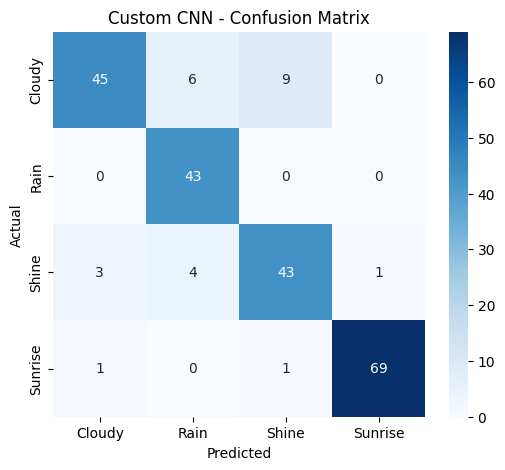

In [22]:
cnn_loss, cnn_accuracy = model.evaluate(X_test, y_test)
print(f"Custom CNN Test Accuracy: {cnn_accuracy:.4f}")

y_true = np.argmax(y_test, axis=1)
y_pred_cnn = np.argmax(model.predict(X_test, batch_size=16), axis=1)

print("\nClassification Report (Custom CNN):")
print(classification_report(y_true, y_pred_cnn, target_names=label_encoder.classes_))

cm_cnn = confusion_matrix(y_true, y_pred_cnn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Custom CNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 46s 6s/step - accuracy: 0.8667 - loss: 0.3470
VGG-16 Test Accuracy: 0.8667
15/15 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step

Classification Report (VGG-16):
              precision    recall  f1-score   support

      Cloudy       0.90      0.92      0.91        60
        Rain       1.00      0.98      0.99        43
       Shine       0.77      0.71      0.73        51
     Sunrise       0.83      0.87      0.85        71

    accuracy                           0.87       225
   macro avg       0.87      0.87      0.87       225
weighted avg       0.87      0.87      0.87       225



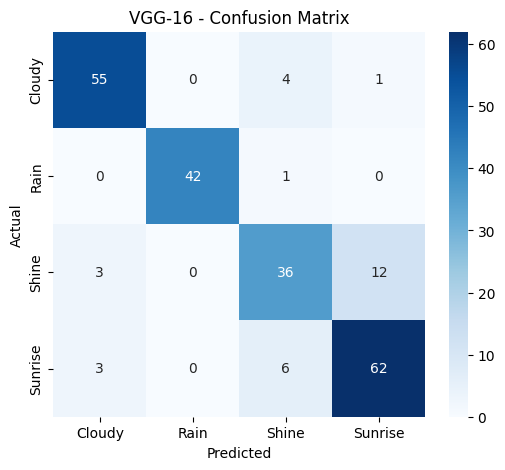

In [23]:
vgg_loss, vgg_accuracy = vgg_model.evaluate(X_test, y_test)
print(f"VGG-16 Test Accuracy: {vgg_accuracy:.4f}")

y_pred_vgg = np.argmax(vgg_model.predict(X_test, batch_size=16), axis=1)

print("\nClassification Report (VGG-16):")
print(classification_report(y_true, y_pred_vgg, target_names=label_encoder.classes_))

cm_vgg = confusion_matrix(y_true, y_pred_vgg)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("VGG-16 - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Training curves

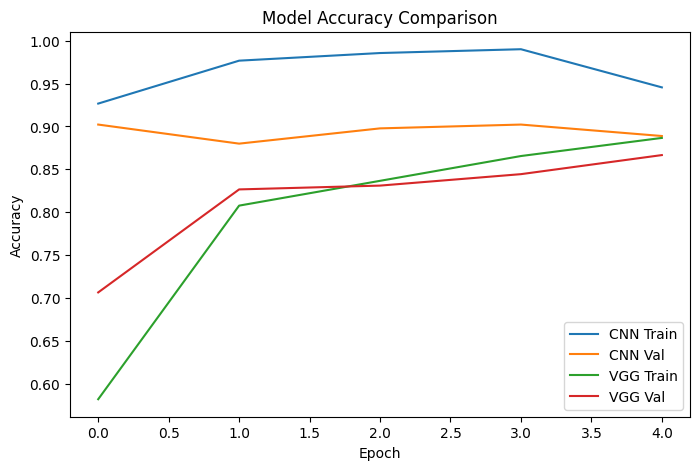

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(cnn_history.history['accuracy'], label='CNN Train')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val')
plt.plot(vgg_history.history['accuracy'], label='VGG Train')
plt.plot(vgg_history.history['val_accuracy'], label='VGG Val')
plt.title("Model Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

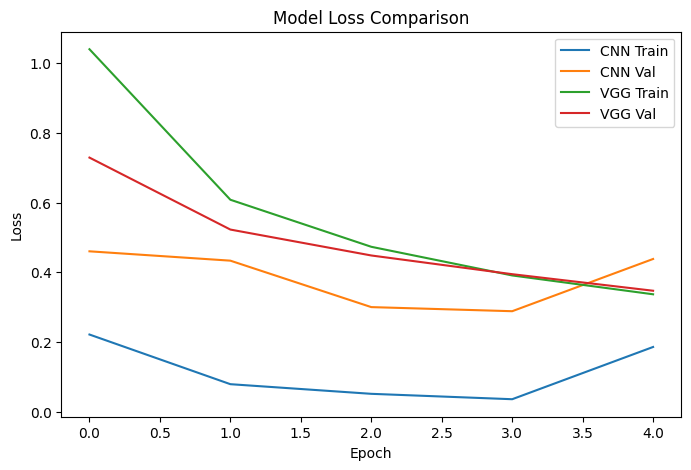

        Model  Test Accuracy
0  Custom CNN       0.888889
1      VGG-16       0.866667


In [25]:
plt.figure(figsize=(8, 5))
plt.plot(cnn_history.history['loss'], label='CNN Train')
plt.plot(cnn_history.history['val_loss'], label='CNN Val')
plt.plot(vgg_history.history['loss'], label='VGG Train')
plt.plot(vgg_history.history['val_loss'], label='VGG Val')
plt.title("Model Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

import pandas as pd

results = pd.DataFrame({
    "Model": ["Custom CNN", "VGG-16"],
    "Test Accuracy": [cnn_accuracy, vgg_accuracy]
})
print(results)